<a href="https://colab.research.google.com/github/Celeste1221/Data-Science-Cohort-20/blob/main/Project-1/Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Transaction Success Prediction

This project analyzes previous transaction data to predict whether a customer will make a transaction.


##Problem Definition

The business problem: We want to predict whether a customer will make a new transaction based on their previous transactions.

This is a supervised binary classification problem because a person either did make a transaction or didn't make a transaction.

The machine learning model is a Gaussian Naive Bayes classification model.

## Data Collection/Sources

This data set comes from AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv

All variable names have been anonymized so they are all considered equally.


##Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.metrics import classification_report
from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

##File Paths

In [ ]:
# csv file
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'

# read file
ds = pd.read_csv(url)

In [ ]:
# create a pandas data frame with the data set
df = pd.DataFrame(ds)

## Data Cleaning and EDA

Examine the data, make a backup copy to clean the data, drop unique identifiers, and handle nulls and duplicates, examine target column for correct values, check feature correlation.


In [ ]:
# get data type of the object, number of entries, number of columns, number of each datatype, how much memory it uses
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [ ]:
# get the shape of the dataframe
df.shape

(1050000, 104)

In [ ]:
# look at the first rows of the dataframe
df.head()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# get the data type of the target
dtype = df['target'].dtype
dtype

dtype('float64')

In [ ]:
# get summary statistics: count, mean, std dev, min, quartiles, and max
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The target data type is a float, the min value in the column is 0.0 and the max value is 1.0, which indicates a binary classification problem.

In [ ]:
# total number of rows in the target column
target_total = len(df['target'])

# count of non nulls in the target column
target_non_nulls = df['target'].count() # only counts non nulls

# count of nulls in the target column
target_nulls = df['target'].isnull().sum()

print(f'There are {target_nulls} nulls out of {target_total} rows in \'target\' ')
print(f'There are total non nulls in \'target\' {target_non_nulls}')

There are 870000 nulls out of 1050000 rows in 'target' 
There are total non nulls in 'target' 180000


The target column has many more nulls than it has actual values.

In [ ]:
# count of each value (nulls, zero's, and one's) in target column
df['target'].value_counts( dropna= False)

,count
target,
NaN,870000
0.0,161960
1.0,18040


In [ ]:
# get the counts as proportions
df['target'].value_counts( normalize=True, dropna= False).mul(100)


,proportion
target,
NaN,82.857143
0.0,15.424762
1.0,1.718095


Roughly 83% of values in the target column are unusable.

In [ ]:
# gives the count of nulls in each column (multiply by 100 to make it stand out)
df.isna().sum().sort_values(ascending=False)

,0
var_3,1050000
var_16,1050000
var_12,1050000
var_11,1050000
var_9,1050000
...,...
var_88,870000
var_94,870000
var_100,870000
Unnamed: 0,0


In [ ]:
# get the number of unique items in each column
nunique = df.nunique().sort_values( ascending = False )
nunique

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


In [ ]:
# create a list of columns with unique ID's to drop
drop_ids = nunique[ nunique == df.shape[0] ].index.to_list()
drop_ids

['Unnamed: 0', 'ID_code']

Unnamed and ID_code unique items  = the total count, so they can be dropped.

In [ ]:
# make a copy of the dataframe before altering it
cleaned = df.copy()
# check that the copy worked
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [ ]:
# drop unique identifiers (Unnamed 0 and ID_code columns)
cleaned.drop( columns = drop_ids, inplace = True)
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 102 entries, target to var_100
dtypes: float64(102)
memory usage: 817.1 MB


In [ ]:
# proportion of values in each column that are nulls
nulls_per_col = cleaned.isna().sum().mul(100).div(len(cleaned)).sort_values(ascending=False)
print(len(cleaned))
nulls_per_col

1050000


,0
var_3,100.000000
var_11,100.000000
var_9,100.000000
var_10,100.000000
var_6,100.000000
...,...
var_88,82.857143
var_86,82.857143
var_85,82.857143
var_94,82.857143


In [ ]:
# drop rows with all nulls and check
cleaned = cleaned.dropna(how='all')
cleaned.isna().sum().mul(100).div(len(cleaned)).sort_values(ascending=False)

,0
var_3,100.0
var_11,100.0
var_9,100.0
var_10,100.0
var_6,100.0
...,...
var_88,0.0
var_86,0.0
var_85,0.0
var_94,0.0


In [ ]:
# number of rows with all nulls
num_rows_all_null = cleaned.isnull().all(axis=1).sum()
num_rows_all_null

np.int64(0)

In [ ]:
# number of columns with all nulls
num_cols_all_null = cleaned.isnull().all(axis=0).sum()
num_cols_all_null

np.int64(51)

In [ ]:
# drop columns with all nulls
cleaned = cleaned.dropna(how='all', axis='columns')

In [ ]:
# number of columns with all nulls
num_cols_all_null = cleaned.isnull().all(axis=0).sum()
num_cols_all_null

np.int64(0)

In [ ]:
cleaned.shape

(180000, 51)

In [ ]:
cleaned.isna().sum().mul(100).div(len(cleaned)).sort_values(ascending=False)

,0
target,0.0
var_0,0.0
var_1,0.0
var_2,0.0
var_4,0.0
var_7,0.0
var_8,0.0
var_14,0.0
var_15,0.0
var_17,0.0


In [ ]:
cleaned.head()

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275


In [ ]:
# check for null counts again
rows = cleaned.isna().any().sum()
cols = cleaned.isna().any(axis=1).sum()

print(f'rows with nulls: {rows} columns witn nulls: {cols}')

rows with nulls: 0 columns witn nulls: 0


In [ ]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 51 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   target   180000 non-null  float64
 1   var_0    180000 non-null  float64
 2   var_1    180000 non-null  float64
 3   var_2    180000 non-null  float64
 4   var_4    180000 non-null  float64
 5   var_7    180000 non-null  float64
 6   var_8    180000 non-null  float64
 7   var_14   180000 non-null  float64
 8   var_15   180000 non-null  float64
 9   var_17   180000 non-null  float64
 10  var_20   180000 non-null  float64
 11  var_21   180000 non-null  float64
 12  var_22   180000 non-null  float64
 13  var_24   180000 non-null  float64
 14  var_26   180000 non-null  float64
 15  var_27   180000 non-null  float64
 16  var_28   180000 non-null  float64
 17  var_29   180000 non-null  float64
 18  var_36   180000 non-null  float64
 19  var_37   180000 non-null  float64
 20  var_38   180000 non-null  floa

In [ ]:
# check shape of cleaned dataframe
cleaned.shape

(180000, 51)

In [ ]:
# check values in the target column (should be 0 or 1 only)
# normalizing gives a relative proportion, naive bayes assumes a normalized dataset
cleaned['target'].value_counts( normalize=True, dropna= False).mul(100)

,proportion
target,
0.0,89.977778
1.0,10.022222


In [ ]:
# Check the correlation values between all **predictor columns only** to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.
# remove target column
predictors = cleaned.drop('target', axis = 'columns')
# get correlations
correlation = predictors.corr()
correlation

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
var_0,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,-0.001353,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,0.001590,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,0.004796,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,-0.000539,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807
var_7,-0.001320,0.000783,-0.000108,-0.002750,1.000000,-0.003199,-0.003588,0.002329,0.004282,-0.001971,...,-0.000412,0.003262,0.002574,-0.001824,0.001186,0.002811,0.001306,0.000236,-0.000568,0.004575
var_8,0.002949,-0.007127,-0.001809,0.003347,-0.003199,1.000000,0.003472,-0.003858,-0.002727,-0.003417,...,-0.008394,-0.004254,-0.002446,0.001117,-0.003713,-0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,1.000000,-0.007115,-0.004249,-0.001595,...,-0.002214,-0.002179,-0.003054,-0.000160,-0.000504,-0.004046,0.003136,0.005715,0.001501,-0.000106
var_15,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,1.000000,0.002467,0.003584,...,0.000581,0.006633,0.004569,-0.001573,0.003251,0.003066,-0.001541,-0.003719,-0.002825,0.004247
var_17,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,1.000000,0.001476,...,0.005578,0.001237,0.000210,-0.002714,0.004149,-0.002182,-0.002642,-0.001968,-0.004100,-0.000822
var_20,-0.001353,0.001590,0.004796,-0.000539,-0.001971,-0.003417,-0.001595,0.003584,0.001476,1.000000,...,-0.001476,0.003107,0.001610,0.001186,0.004265,0.001449,-0.004506,-0.003241,-0.000988,0.001734


In [ ]:
# Create a boolean mask for the upper triangle (excluding the diagonal)
mask = np.triu(np.ones_like(correlation, dtype=bool))

# Apply the mask to the correlation matrix, setting the lower triangle and diagonal to NaN
masked_corr_matrix = correlation.where(~mask)
masked_corr_matrix


,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
var_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_1,-0.000892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_2,-0.000225,0.006064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_4,-0.000269,-0.000821,-0.003427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_7,-0.001320,0.000783,-0.000108,-0.002750,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_8,0.002949,-0.007127,-0.001809,0.003347,-0.003199,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_14,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_15,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_17,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_20,-0.001353,0.001590,0.004796,-0.000539,-0.001971,-0.003417,-0.001595,0.003584,0.001476,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# reference: https://stackoverflow.com/questions/41128456/pandas-filter-across-all-columns

# .stack() method pivots the columns to the rows and automatically
# removes nulls
high_corr_pairs = masked_corr_matrix.stack()

# set threshold to correlations 0.8 or above
threshold = 0.8
# filter the correlation matrix to see if there are any highly correlated features
filtered_pairs = high_corr_pairs[high_corr_pairs >= threshold]

print(filtered_pairs)


Series([], dtype: float64)


There are no pairs with a correlation greater than 0.8 in the correlation matrix so we can keep all the features.

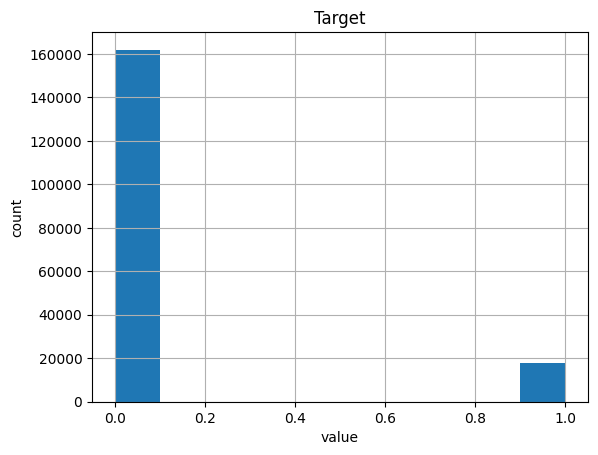

In [ ]:
# histogram of target column
cleaned['target'].hist()
plt.title('Target')
plt.xlabel('value')
plt.ylabel('count')
plt.show()

The target data is not normally distributed.



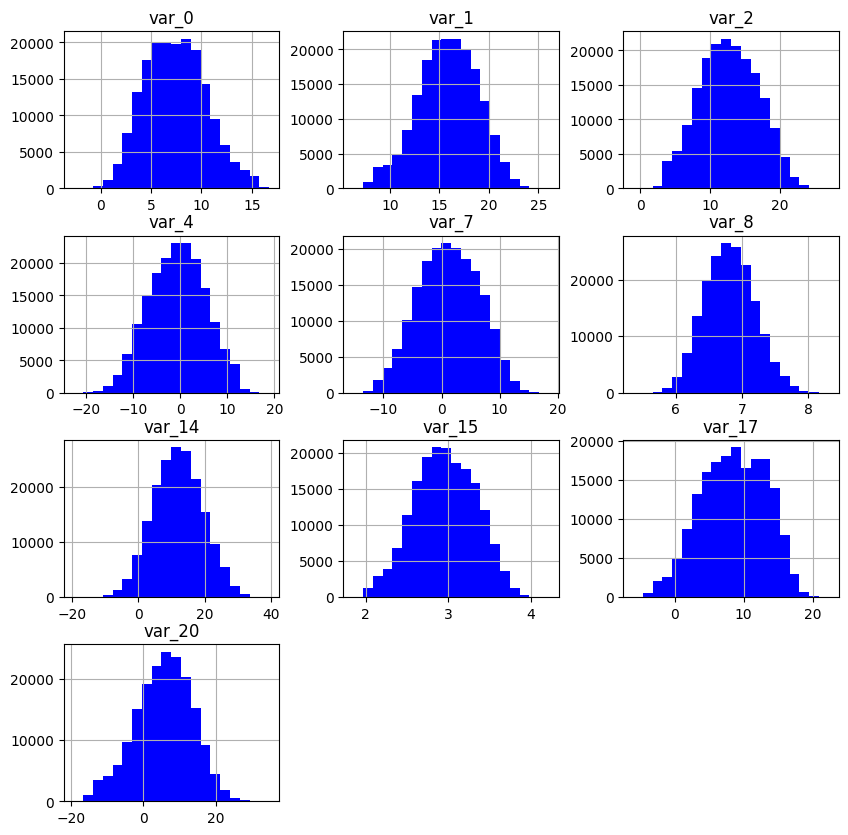

In [ ]:
# Select the first 10 predictors
N = 10
predictors_subset = predictors.iloc[:, :N]

# plot them
predictors_subset.hist(figsize=(10,10), bins=20, color='blue')
plt.xlabel('value')
plt.ylabel('count')
plt.show()

The predictors appear to have a relatively normal distributions.

In [ ]:
# first make a copy of the cleaned dataset
cleaned_copy = cleaned.copy()

# create data frame of all sucessful transactions
success = cleaned_copy[cleaned_copy['target'] == 1]

# create data frame of all unsuccessful transactions
unsuccess = cleaned_copy[cleaned_copy['target'] != 1]

success.head(), unsuccess.head()


(     target   var_0    var_1    var_2    var_4    var_7   var_8   var_14  \
 57      1.0  8.9078  12.1321   9.4707  -5.8102   0.4521  7.1264  15.6935   
 125     1.0  6.2143  20.0990  23.5009  -0.8917  -3.9167  6.6863  21.4162   
 151     1.0  8.9083  12.1117  18.0359  -4.9628  10.1135  6.8962  11.4553   
 155     1.0  6.5612  13.9638   5.1980  12.1092   8.4874  6.4781  16.9541   
 302     1.0  4.4616   9.7572  12.9317   7.6485   0.6382  5.8025  22.4577   
 
      var_15   var_17  ...   var_83  var_84  var_85   var_86   var_87  var_88  \
 57   2.6980   4.3336  ...  11.2059  4.0237  5.8905  12.4865  10.1419  2.3370   
 125  2.8672   6.4550  ...  10.8110  3.9190  7.4971  35.7428   9.6149  2.2257   
 151  2.6735   2.1990  ...  11.6326  3.9193  5.0366  37.1453  17.0341  0.9987   
 155  2.0573   5.5008  ...  11.2981  4.1316  7.2193  -1.8139   1.8190  2.5720   
 302  3.0906  16.2501  ...  11.5449  4.0001  9.0639  11.8805   9.4678  1.0561   
 
      var_89   var_92   var_94  var_100  
 57  -

In [ ]:
# check values
success['target'].value_counts()

,count
target,
1.0,18040


In [ ]:
# check values
unsuccess['target'].value_counts()

,count
target,
0.0,161960


In [ ]:
# create a dataframe with just the target
targets = cleaned_copy['target']

# check head
targets.head()

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0


In [ ]:
# check lengths of each dataframe
len(success), len(unsuccess), len(cleaned), len(predictors), len(targets)

(18040, 161960, 180000, 180000, 180000)

## Data Processing

The model used is a Gaussian Naive Bayes model, which assumes a normal distribution and features that are no correlated.






In [ ]:
# Define a Gaussian Naïve Bayes model using Sklearn.
gnb = GaussianNB()

In [ ]:
# features
X = predictors
# target
y = targets

X.shape, y.shape

((180000, 50), (180000,))

In [ ]:
# Divide the x and y dataframes into training and testing subsets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y )

In [ ]:
# train model using training subset
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Round 1: single cross validation

#Test the model using the testing subset of the dataset.
y_pred = gnb.predict(X_test)

#Calculate and report the accuracy.
(y_test - y_pred).add(-1).abs().mul(100).mean()


np.float64(93.40555555555555)

93% accuracy seems very high for one training pass.

In [ ]:
# Round 2: multiple cross validation
n = 100
results = np.zeros(n)

for i in range(n):
  # Divide the x and y data frames into training and testing subsets.
  X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y )

  # fit (train) the model using the training subset
  gnb.fit(X_train, y_train)

  # test using the testing subset
  y_pred = gnb.predict(X_test)

  # calculate the accuracy
  results[i] = 1-(y_test - y_pred).abs().mean()


In [ ]:
# report accuracy
imbalanced_accuracy = results.mean()*100
imbalanced_accuracy

np.float64(87.23052777777777)

The accuracy of the model has decreased, even though there were more training passes.

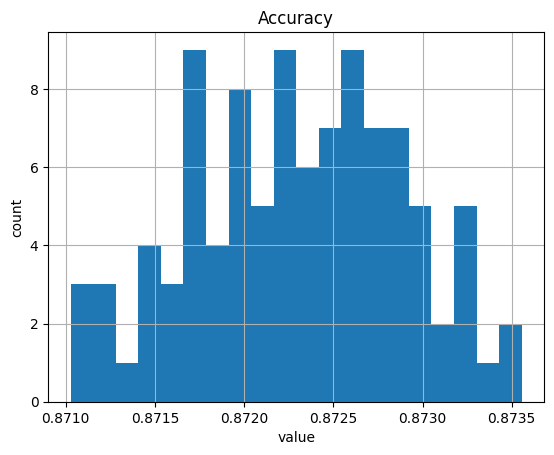

In [ ]:
# Plot a histogram of the accuracy scores generated in
# round 2, i.e. the first multiple cross_validation

# average correct
pd.Series(results).hist(bins=20)

plt.xlabel('value')
plt.ylabel('count')
plt.title('Accuracy')

plt.show()

Accuracy results are not normally distributed.

Text(0.5, 1.0, 'Confusion matrix')

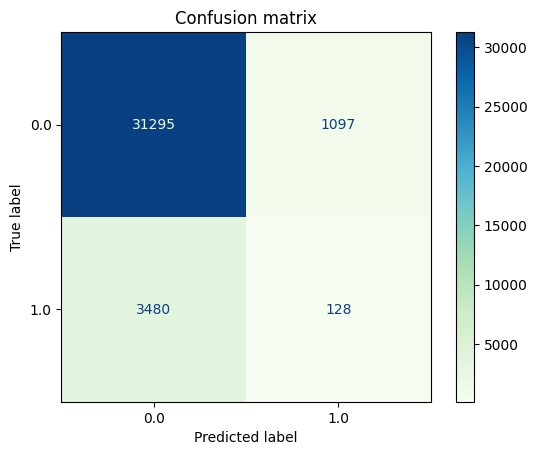

In [ ]:
# plot a confusion matrix of the first multiple cross-validation, i.e. round 2
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix')

In [ ]:
# print classification report for round 2
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93     32392
         1.0       0.10      0.04      0.05      3608

    accuracy                           0.87     36000
   macro avg       0.50      0.50      0.49     36000
weighted avg       0.82      0.87      0.84     36000



The f1 score for no transaction completed is very high but for transaction completed it is much lower because there are so many more no transaction completed features in the dataset.

In [ ]:
# balance the dataset:
# remove enough non-successful transaction rows so that
# training data is a 50/50 split between non-successful
# transactions and successful transactions using random
# undersampling

# find the size of the smallest group
min_size = cleaned['target'].value_counts().min()

# group by the target and sample 'min_size from each
cleaned_bal = cleaned.groupby('target').sample(n=min_size, random_state=42)

cleaned_bal.shape


(36080, 51)

In [ ]:
# dataset is now balanced
cleaned_bal['target'].value_counts(normalize=True).to_frame().style.format("{:.1%}")

,proportion
target,
0.000000,50.0%
1.000000,50.0%



1. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.

In [ ]:
# balanced targets
targets_bal = cleaned_bal['target']

# balanced predictors
predictors_bal = cleaned_bal.drop('target', axis = 'columns')

predictors_bal.shape, targets_bal.shape

((36080, 50), (36080,))

In [ ]:
# features
X = predictors_bal
# target
y = targets_bal

X.shape, y.shape

# ((180000, 50), (180000,))

((36080, 50), (36080,))

In [ ]:
# repeat cross-validation on the 50/50 case
# multiple cross validation

n = 100
results = np.zeros(n)

for i in range(n):
  # Divide the x and y data frames into training and testing subsets.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y )

  # create the model
  gnb = GaussianNB()

  # fit (train) the model using the training subset
  gnb.fit(X_train,y_train)

  # test the model
  y_pred = gnb.predict(X_test)

  # performance
  results[i] = 1-(y_test - y_pred).abs().mean()


In [ ]:
# calculate accuracy
balanced_accuracy = f"{results.mean():.3%}"
balanced_accuracy

'75.269%'

With a balanced dataset, accuracy is even further decreased.

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data

1. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)




In [ ]:
# compare results # compare cross-validation results of whole dataset training vs reduced dataset training
print(f'Imbalanced whole dataset accuracy: {imbalanced_accuracy} vs balanced reduced dataset accuracy: {balanced_accuracy}.')

Imbalanced whole dataset accuracy: 87.23052777777777 vs balanced reduced dataset accuracy: 75.269%.


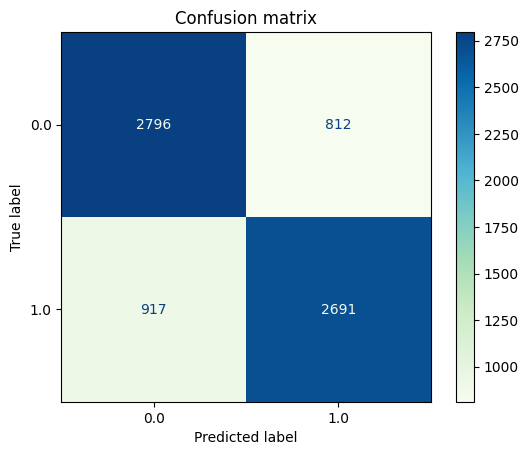

In [ ]:
# present confusion matrix and results of classification report for round 3
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix') ;


<Axes: >

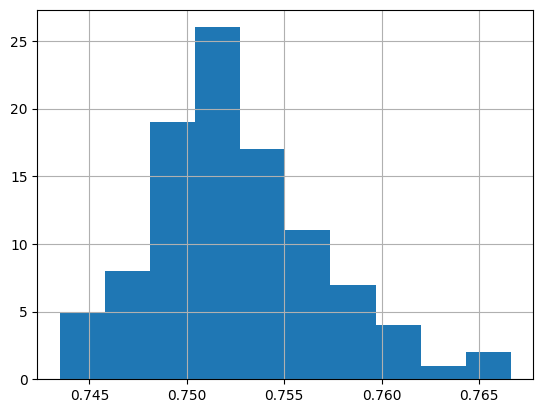

In [ ]:
pd.Series(results).hist()

In [ ]:
# classification report for round 3
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76      3608
         1.0       0.77      0.75      0.76      3608

    accuracy                           0.76      7216
   macro avg       0.76      0.76      0.76      7216
weighted avg       0.76      0.76      0.76      7216



## Communicate the Results

Conclusion:

The model trained on the whole dataset has a higher accuracy but this is not valid because the dataset was heavily weighted towards the unsuccessful transactions. The model trained on the balanced dataset has a lower but valid accuracy because there were an equal number of successful and unsucessful transactions in the training dataset.


Future ideas:

1. Change the hyperparameters to increase accuracy with the balanced dataset.
2. Try other ways to balance the dataset to increase the accuracy.
3. Try a different model to increase the accuracy.




